# Stakeholder Review: Housing Price ML Pipeline

This notebook is the stakeholder-facing summary for the current housing price pipeline. It uses the generated project artifacts to explain the dataset, data-quality posture, transformation impact, and baseline model performance in business terms.

Artifacts used:
- raw dataset from `data/raw/usa-housing-dataset/USA Housing Dataset.csv`
- transformation metadata from `artifacts/processed/usa_housing_transformed.metadata.json`
- trained model metadata from `artifacts/models/linear_regression_model.metadata.json`
- evaluation metrics from `artifacts/evaluation/linear_regression_metrics.json`


## Analysis Types We Can Run In This Project

For this project, the useful analysis categories are:

1. **Data availability and provenance analysis**: where the data came from, when artifacts were generated, and whether the dataset is stable and reproducible.
2. **Data quality analysis**: schema checks, missing values, duplicates, invalid values, and contract violations.
3. **Market and pricing analysis**: price distribution, segment behavior, inventory profile, and concentration by city or home characteristics.
4. **Transformation impact analysis**: what rows or fields were removed or derived before modeling, and how much data was retained.
5. **Feature readiness analysis**: which variables are usable for modeling and which fields were intentionally excluded.
6. **Model performance analysis**: MAE, RMSE, R2, train/test split, and whether the current baseline is operationally credible.
7. **Prediction error analysis**: where the model overshoots or undershoots, and which segments are most unstable.
8. **Operational readiness analysis**: artifact lineage, deterministic splits, reproducibility, and next steps for production hardening.

This notebook implements the stakeholder-facing subset: data availability, data quality, market profile, transformation impact, model performance, and prediction error analysis.


In [2]:
from __future__ import annotations

import json
import pickle
from pathlib import Path

try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        "Notebook dependencies are missing. Install them with: python -m pip install -e '.[notebooks]'"
    ) from exc

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None
    display = print

from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format


def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'main.py').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate the project root. Run this notebook from the local repository, or clone the repo into the current runtime.'
    )


REPO_ROOT = find_repo_root(Path.cwd())
RAW_DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'usa-housing-dataset' / 'USA Housing Dataset.csv'
TRANSFORMED_DATA_PATH = REPO_ROOT / 'artifacts' / 'processed' / 'usa_housing_transformed.csv'
TRANSFORM_META_PATH = REPO_ROOT / 'artifacts' / 'processed' / 'usa_housing_transformed.metadata.json'
MODEL_META_PATH = REPO_ROOT / 'artifacts' / 'models' / 'linear_regression_model.metadata.json'
MODEL_ARTIFACT_PATH = REPO_ROOT / 'artifacts' / 'models' / 'linear_regression_model.pkl'
EVAL_METRICS_PATH = REPO_ROOT / 'artifacts' / 'evaluation' / 'linear_regression_metrics.json'
EVAL_META_PATH = REPO_ROOT / 'artifacts' / 'evaluation' / 'linear_regression_evaluation.metadata.json'

required_paths = [
    RAW_DATA_PATH,
    TRANSFORMED_DATA_PATH,
    TRANSFORM_META_PATH,
    MODEL_META_PATH,
    MODEL_ARTIFACT_PATH,
    EVAL_METRICS_PATH,
    EVAL_META_PATH,
]

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(f'Missing pipeline artifacts:\n{formatted}\nRun python main.py before opening this notebook.')

print(f'Repo root: {REPO_ROOT}')
print(f'Raw data: {RAW_DATA_PATH}')
print(f'Transformed data: {TRANSFORMED_DATA_PATH}')


Repo root: /Users/pranavchourasiya/pranav/house-price-ml
Raw data: /Users/pranavchourasiya/pranav/house-price-ml/data/raw/usa-housing-dataset/USA Housing Dataset.csv
Transformed data: /Users/pranavchourasiya/pranav/house-price-ml/artifacts/processed/usa_housing_transformed.csv


In [3]:
raw_df = pd.read_csv(RAW_DATA_PATH)
transformed_df = pd.read_csv(TRANSFORMED_DATA_PATH)
transform_meta = json.loads(TRANSFORM_META_PATH.read_text(encoding='utf-8'))
model_meta = json.loads(MODEL_META_PATH.read_text(encoding='utf-8'))
evaluation_metrics = json.loads(EVAL_METRICS_PATH.read_text(encoding='utf-8'))
evaluation_meta = json.loads(EVAL_META_PATH.read_text(encoding='utf-8'))

raw_df['date'] = pd.to_datetime(raw_df['date'])
raw_df['price'] = pd.to_numeric(raw_df['price'])
transformed_df['price'] = pd.to_numeric(transformed_df['price'])

with MODEL_ARTIFACT_PATH.open('rb') as file_obj:
    model_artifact = pickle.load(file_obj)

target_column = model_artifact['target_column']
numeric_feature_columns = list(model_artifact['numeric_feature_columns'])
categorical_feature_columns = list(model_artifact['categorical_feature_columns'])
feature_columns = numeric_feature_columns + categorical_feature_columns

feature_rows = transformed_df[feature_columns].to_dict(orient='records')
targets = transformed_df[target_column].astype(float).tolist()

_, X_test, _, y_test = train_test_split(
    feature_rows,
    targets,
    test_size=evaluation_meta['test_size'],
    random_state=evaluation_meta['random_state'],
)

predictions = model_artifact['pipeline'].predict(X_test)
predictions_df = pd.DataFrame(X_test)
predictions_df['actual_price'] = y_test
predictions_df['predicted_price'] = predictions
predictions_df['absolute_error'] = (predictions_df['predicted_price'] - predictions_df['actual_price']).abs()
predictions_df['signed_error'] = predictions_df['predicted_price'] - predictions_df['actual_price']
predictions_df['ape_percent'] = (predictions_df['absolute_error'] / predictions_df['actual_price']) * 100

raw_city_counts = raw_df['city'].value_counts()
price_by_city = transformed_df.groupby('city')['price'].agg(['count', 'median', 'mean']).sort_values('count', ascending=False)
price_by_bedrooms = transformed_df.groupby('bedrooms')['price'].agg(['count', 'median', 'mean']).reset_index()

drop_rate = transform_meta['dropped_row_count'] / transform_meta['input_row_count']
price_summary = transformed_df['price'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
top_city = raw_city_counts.index[0]
top_city_count = int(raw_city_counts.iloc[0])


## Executive Summary


In [4]:
summary_df = pd.DataFrame(
    [
        {'Metric': 'Raw rows', 'Value': int(transform_meta['input_row_count'])},
        {'Metric': 'Rows retained for modeling', 'Value': int(transform_meta['output_row_count'])},
        {'Metric': 'Rows dropped before modeling', 'Value': int(transform_meta['dropped_row_count'])},
        {'Metric': 'Drop rate', 'Value': f'{drop_rate:.2%}'},
        {'Metric': 'Model', 'Value': evaluation_metrics['model_name']},
        {'Metric': 'Held-out rows evaluated', 'Value': int(evaluation_metrics['evaluated_row_count'])},
        {'Metric': 'MAE', 'Value': f"${evaluation_metrics['mae']:,.0f}"},
        {'Metric': 'RMSE', 'Value': f"${evaluation_metrics['rmse']:,.0f}"},
        {'Metric': 'R2', 'Value': f"{evaluation_metrics['r2']:.3f}"},
        {'Metric': 'Median sale price', 'Value': f"${price_summary['50%']:,.0f}"},
        {'Metric': '90th percentile sale price', 'Value': f"${price_summary['90%']:,.0f}"},
        {'Metric': 'Most represented city', 'Value': f'{top_city} ({top_city_count} listings)'},
    ]
)
summary_df


,Metric,Value
0,Raw rows,4140
1,Rows retained for modeling,4091
2,Rows dropped before modeling,49
3,Drop rate,1.18%
4,Model,linear_regression
5,Held-out rows evaluated,819
6,MAE,"$129,056"
7,RMSE,"$239,475"
8,R2,0.639
9,Median sale price,"$464,600"


In [5]:
stakeholder_takeaways = f"""
- The pipeline starts with **{transform_meta['input_row_count']:,}** raw records and retains **{transform_meta['output_row_count']:,}** records for modeling.
- **{transform_meta['dropped_row_count']:,}** records (**{drop_rate:.2%}**) were excluded because the target price was non-positive.
- The current baseline model explains about **{evaluation_metrics['r2']:.1%}** of held-out price variance.
- On the held-out test set, the average absolute miss is **${evaluation_metrics['mae']:,.0f}** per property.
- The market is concentrated in **{top_city}**, which contributes **{top_city_count:,}** listings in the raw sample.
"""
if Markdown is not None:
    display(Markdown(stakeholder_takeaways))
else:
    print(stakeholder_takeaways)



- The pipeline starts with **4,140** raw records and retains **4,091** records for modeling.
- **49** records (**1.18%**) were excluded because the target price was non-positive.
- The current baseline model explains about **63.9%** of held-out price variance.
- On the held-out test set, the average absolute miss is **$129,056** per property.
- The market is concentrated in **Seattle**, which contributes **1,415** listings in the raw sample.


## Data Quality And Transformation Impact


In [6]:
quality_df = pd.DataFrame(
    {
        'Metric': [
            'Duplicate raw rows',
            'Raw rows with non-positive price',
            'Raw rows with missing values',
            'Derived columns added',
            'Columns dropped before modeling',
        ],
        'Value': [
            int(raw_df.duplicated().sum()),
            int((raw_df['price'] <= 0).sum()),
            int(raw_df.isna().any(axis=1).sum()),
            ', '.join(transform_meta['derived_columns']),
            ', '.join(transform_meta['drop_columns']),
        ],
    }
)
quality_df


,Metric,Value
0,Duplicate raw rows,0
1,Raw rows with non-positive price,49
2,Raw rows with missing values,0
3,Derived columns added,"state, zipcode, sale_year, sale_month, sale_day"
4,Columns dropped before modeling,"street, country, statezip, date"


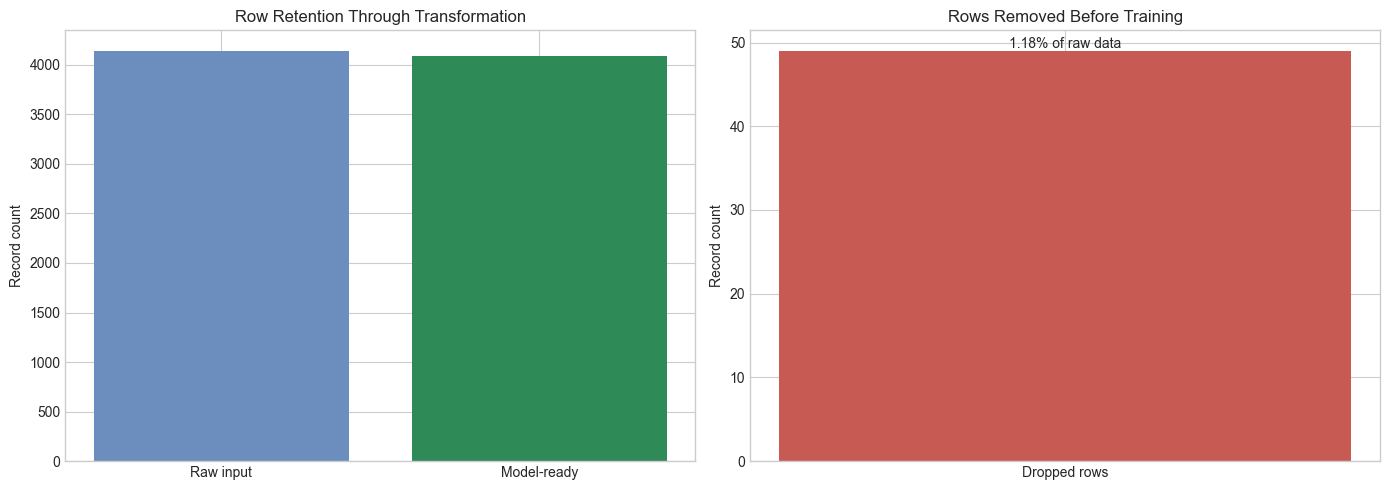

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Raw input', 'Model-ready'], [transform_meta['input_row_count'], transform_meta['output_row_count']], color=['#6c8ebf', '#2e8b57'])
axes[0].set_title('Row Retention Through Transformation')
axes[0].set_ylabel('Record count')

axes[1].bar(['Dropped rows'], [transform_meta['dropped_row_count']], color=['#c85a54'])
axes[1].set_title('Rows Removed Before Training')
axes[1].set_ylabel('Record count')
axes[1].text(0, transform_meta['dropped_row_count'], f"{drop_rate:.2%} of raw data", ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Market Profile And Pricing Analysis


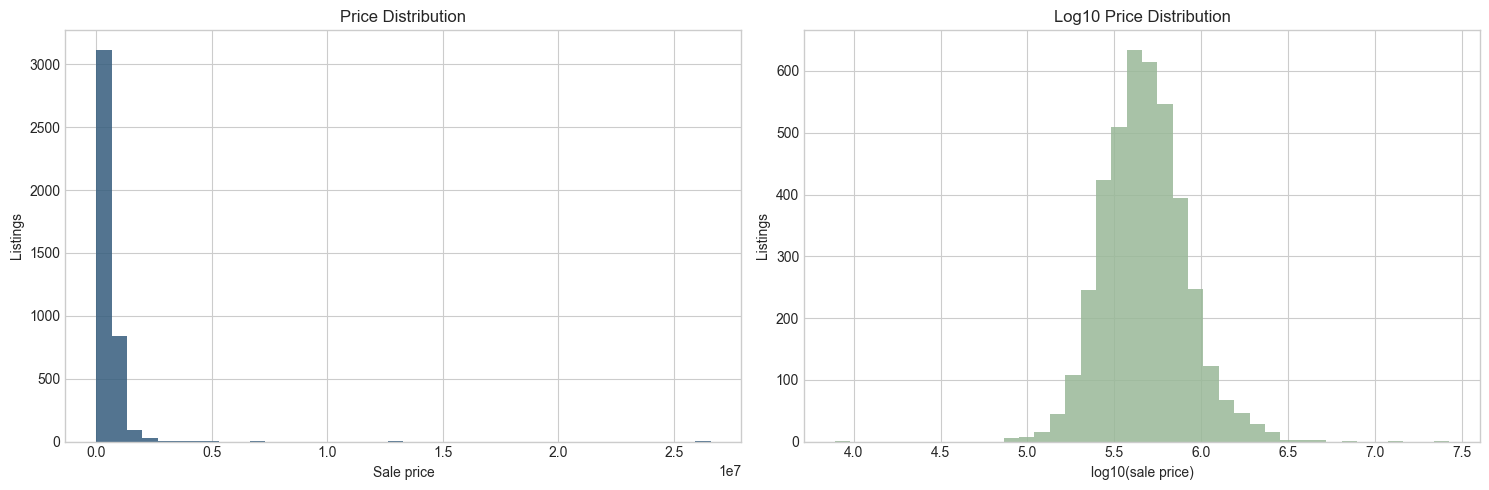

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(transformed_df['price'], bins=40, color='#355c7d', alpha=0.85)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Sale price')
axes[0].set_ylabel('Listings')

axes[1].hist(transformed_df['price'].clip(lower=1).map(__import__('math').log10), bins=40, color='#99b898', alpha=0.85)
axes[1].set_title('Log10 Price Distribution')
axes[1].set_xlabel('log10(sale price)')
axes[1].set_ylabel('Listings')

plt.tight_layout()
plt.show()


In [ ]:
top_cities = price_by_city.head(10).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_cities['city'], top_cities['count'], color='#4f81bd')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Cities By Listing Count')
axes[0].set_xlabel('Listings')

top_median_price = price_by_city.sort_values('median', ascending=False).head(10).reset_index()
axes[1].barh(top_median_price['city'], top_median_price['median'], color='#c06c84')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Cities By Median Price')
axes[1].set_xlabel('Median price')

plt.tight_layout()
plt.show()

top_cities[['city', 'count', 'median', 'mean']]


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(price_by_bedrooms['bedrooms'], price_by_bedrooms['median'], marker='o', linewidth=2, color='#2a9d8f')
ax.set_title('Median Price By Bedroom Count')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Median price')
plt.tight_layout()
plt.show()

price_by_bedrooms


## Model Performance And Error Analysis


In [ ]:
model_health_df = pd.DataFrame(
    [
        {'Metric': 'Model name', 'Value': evaluation_metrics['model_name']},
        {'Metric': 'Train rows', 'Value': int(model_meta['train_row_count'])},
        {'Metric': 'Test rows', 'Value': int(model_meta['test_row_count'])},
        {'Metric': 'Encoded feature count', 'Value': int(model_meta['encoded_feature_count'])},
        {'Metric': 'MAE', 'Value': f"${evaluation_metrics['mae']:,.0f}"},
        {'Metric': 'RMSE', 'Value': f"${evaluation_metrics['rmse']:,.0f}"},
        {'Metric': 'R2', 'Value': f"{evaluation_metrics['r2']:.3f}"},
    ]
)
model_health_df


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(predictions_df['actual_price'], predictions_df['predicted_price'], alpha=0.45, color='#355c7d')
min_price = min(predictions_df['actual_price'].min(), predictions_df['predicted_price'].min())
max_price = max(predictions_df['actual_price'].max(), predictions_df['predicted_price'].max())
axes[0].plot([min_price, max_price], [min_price, max_price], linestyle='--', color='black')
axes[0].set_title('Actual vs Predicted Price')
axes[0].set_xlabel('Actual price')
axes[0].set_ylabel('Predicted price')

axes[1].hist(predictions_df['signed_error'], bins=30, color='#f67280', alpha=0.85)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Predicted - actual')
axes[1].set_ylabel('Properties')

plt.tight_layout()
plt.show()


In [ ]:
segment_error_df = predictions_df.groupby('city').agg(
    listings=('actual_price', 'size'),
    mean_absolute_error=('absolute_error', 'mean'),
    mean_ape_percent=('ape_percent', 'mean'),
).sort_values('mean_absolute_error', ascending=False)

high_error_segments = segment_error_df[segment_error_df['listings'] >= 5].head(10).reset_index()
largest_misses = predictions_df.sort_values('absolute_error', ascending=False).head(10)[
    ['actual_price', 'predicted_price', 'absolute_error', 'ape_percent', 'city', 'bedrooms', 'bathrooms', 'sqft_living']
]

high_error_segments


In [ ]:
largest_misses


## Stakeholder Implications

Current readout:
- The pipeline is operational end-to-end: ingestion, validation, transformation, training, and evaluation all produce versioned artifacts.
- The data cleaning step removes clearly unusable target values, but there is still model error large enough to matter for pricing use cases.
- The current `linear_regression` model is a baseline, not the final production model. It is useful for proving the pipeline, feature contract, and evaluation loop.
- The next value-adding analyses are feature importance proxies, richer segment-level error analysis, and comparison against stronger models such as tree-based regressors.

Recommended next actions for stakeholders:
1. Approve the data contract and transformation rules as the current baseline.
2. Use this notebook as the recurring project review artifact for data and model status.
3. Fund the next iteration around model comparison and segment-specific error reduction before exposing predictions to end users.
